# EDA of Wine Data for Data Preparation and Subsequent Dataset Modeling

# Preliminary Steps, Data Loading, and Functions

[ESP] Exploración de Datos Vinos para Data Preparation y posterior Modelización del conjunto de datos.

Preliminares y carga de datos y funciones

In [20]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)



Mounted at /content/drive


In [21]:
# Access to data
import sys
sys.path.append('/content/drive/MyDrive/Material Minería de Datos 2025_26 Gr2')

execfile("/content/drive/MyDrive/Mineria de datos/Mineria de datos/NuestrasFunciones.py")

In [22]:
!pip install missingno
!pip install feature_engine
!pip install pyarrow
!pip install seaborn

In this project, different approaches to exploring and cleaning a dataset are examined, with a specific application to a wine sales dataset. The data cleaning and preparation phase is crucial for obtaining predictive models that are as free as possible from bias and estimation issues. We will explore several available alternatives for data cleaning and preparation based on the nature of the distributions of the variables involved.

[ESP] En este practica se exploran distintas posibilidades de estudio y depuración de un conjunto de datos con aplicación concreta a un dataset de venta de vinos. La fase de "limpieza" y preparación de los datos es a crucial de cara a la obtención de modelos predictivos lo más libres posible de sesgos y problemas de estimación, exploraremos varias alternativas de las disponibles para limpieza y preparación de datos en base a la naturaleza de las distribuciones de las variables implicadas.






# Descriptive data analysis of wine sales.

[ESP] Estudio descriptivo de datos sobre venta de vinos.


In [23]:
vinos = pd.read_csv('/content/drive/MyDrive/Mineria de datos/Mineria de datos/Datos/DatosVino.csv')
vinos.head()
vinos


,ID,Beneficio,Compra,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,Etiqueta,CalifProductor,Clasificacion,Region,PrecioBotella
0,2,515,1,0.16,-0.81,26.10,-0.425,1.02792,3.38,0.70,144.0,M,2,***,1.0,1.00
1,4,585,1,2.64,-0.88,14.80,0.037,0.99518,3.12,0.48,22.0,M,3,***,3.0,3.38
2,8,0,0,0.29,-0.40,21.50,0.060,0.99572,3.49,1.21,10.3,R,3,?,1.0,3.72
3,11,775,1,-1.22,0.34,1.40,0.040,1.03236,3.20,NaN,11.6,B,2,***,2.0,6.23
4,12,596,1,0.27,1.05,11.25,-0.007,0.99620,4.93,0.26,15.0,R,1,?,2.0,2.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6360,16111,0,0,0.39,0.17,2.30,0.099,1.00223,4.28,0.12,9.8,R,4,*,1.0,1.28
6361,16112,886,1,0.69,0.09,53.90,0.044,0.99480,3.55,NaN,112.0,MB,2,***,3.0,4.19
6362,16113,477,1,0.33,-0.94,-42.50,0.036,0.97287,2.99,NaN,14.0,R,4,**,1.0,1.81
6363,16127,614,1,0.17,-1.10,37.00,0.078,0.99076,3.25,NaN,12.3,R,1,**,2.0,1.00


## First Steps

1- **Variable types.** info().

2- **Miscoded values.** Are there undeclared missing values such as -1 or 99999? Do the nominal categories match what they should be?

3- **Out-of-range values.** Are there any variables with range limitations that are not being met?

4- **Nominal variables or factors with underrepresented categories.** Categories with low representation can cause many problems in models due to insufficient sample size. It is a good practice to review and recode these variables by merging poorly represented categories with others that show similar behavior according to the target variable.

5- **Outliers.** Incidence and treatment (convert to missing, remove, winsorize).

6- **Missing values.** Incidence and treatment (remove, simple imputation using mean, median, random values, or model-based imputation).

### Variable Types

---

[ESP] **Primeros pasos**


1- **Tipos de variables**.

2- **Valores mal codificados**. Hay missings no declarados tipo -1, 99999? Las categorías de las nominales son las que deben?

3- **Valores fuera de rango**. Hay alguna limitación sobre el rango de alguna variable que no se cumpla?

4- **Variables nominales o Factores con categorías minoritarias**. Las categorías con baja representación pueden causar muchos problemas en los modelos por falta de base muestral, es conveniente echar un vistazo y recodificar las variables uniendo categorías muy poco representativas con otras cuya unión tenga algún comportamiento similar frente a la objetivo.

5- **Outliers**. Incidencia y tratamiento (pasar a missing, eliminar, winsorizar)

6- **Missings**. Incidencia y tratamiento (Eliminar, imputación simple por media, mediana, aleatorio, imputación por modelos)


**Tipos de variables**




In [24]:
# Info
vinos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              6365 non-null   int64  
 1   Beneficio       6365 non-null   int64  
 2   Compra          6365 non-null   int64  
 3   Acidez          6365 non-null   float64
 4   AcidoCitrico    6365 non-null   float64
 5   Azucar          6365 non-null   float64
 6   CloruroSodico   6066 non-null   float64
 7   Densidad        6365 non-null   float64
 8   pH              6170 non-null   float64
 9   Sulfatos        5761 non-null   float64
 10  Alcohol         6365 non-null   float64
 11  Etiqueta        6365 non-null   object 
 12  CalifProductor  6365 non-null   int64  
 13  Clasificacion   6365 non-null   object 
 14  Region          6258 non-null   float64
 15  PrecioBotella   6365 non-null   float64
dtypes: float64(10), int64(4), object(2)
memory usage: 795.8+ KB


Not all variables have been assigned the correct data type. We identify factors such as 'Compra' (column 3), 'Etiqueta' (column 12), 'Clasificacion' (column 14), and 'Region' (column 15).





In [25]:
# Unique values for variable
vinos.nunique()


,0
ID,6365
Beneficio,983
Compra,2
Acidez,659
AcidoCitrico,523
Azucar,1639
CloruroSodico,1406
Densidad,3614
pH,436
Sulfatos,543


<Axes: xlabel='CalifProductor', ylabel='count'>

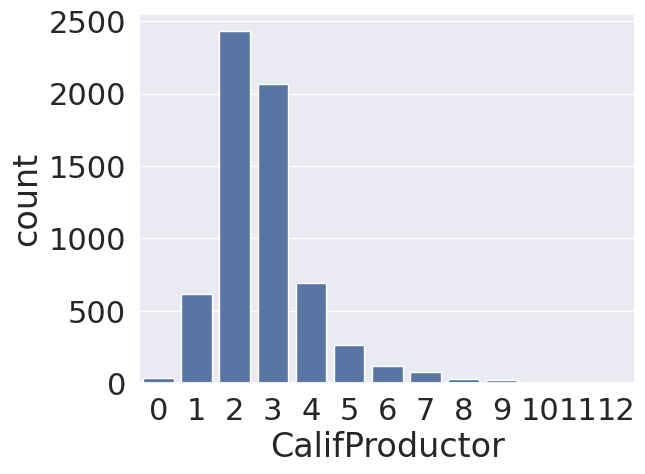

In [26]:
import plotly.express as px

import seaborn as sns

#fig = px.histogram(vinos, x="CalifProductor")
sns.countplot(vinos,x="CalifProductor")
#fig.show()


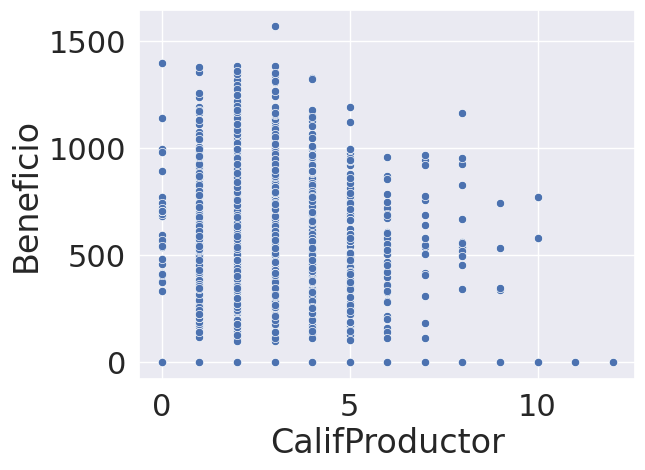

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.clf()
sns.scatterplot(data=vinos, x="CalifProductor", y="Beneficio")#, hue="Compra")
#sns.boxplot(x='long',y='Luxury',data=viviendasDep,palette='viridis')
plt.show()

### We will transform to factor every variable with less than 10 unique values.



In [28]:
to_factor = list(vinos.loc[:,vinos.nunique() <= 10]);
print(to_factor)

vinos[to_factor] = vinos[to_factor].astype('category')


['Compra', 'Etiqueta', 'Clasificacion', 'Region']


Verify the info with the new variable types.




In [29]:
vinos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              6365 non-null   int64   
 1   Beneficio       6365 non-null   int64   
 2   Compra          6365 non-null   category
 3   Acidez          6365 non-null   float64 
 4   AcidoCitrico    6365 non-null   float64 
 5   Azucar          6365 non-null   float64 
 6   CloruroSodico   6066 non-null   float64 
 7   Densidad        6365 non-null   float64 
 8   pH              6170 non-null   float64 
 9   Sulfatos        5761 non-null   float64 
 10  Alcohol         6365 non-null   float64 
 11  Etiqueta        6365 non-null   category
 12  CalifProductor  6365 non-null   int64   
 13  Clasificacion   6365 non-null   category
 14  Region          6258 non-null   category
 15  PrecioBotella   6365 non-null   float64 
dtypes: category(4), float64(9), int64(3)
memory usage: 622.5 KB


At first glance, the only unusual variable is Label, which should not have so many distinct values.


[ESP] En principio la única cosa rara es la variable Etiqueta que no debería tener tantos valores distintos.


### Descriptive statistics for the variables


In [30]:
vinos.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
ID,6365.0,8010.7,4654.9,2.0,3980.0,8065.0,12027.0,16128.0
Beneficio,6365.0,452.4,308.4,0.0,236.0,480.0,671.0,1568.0
Acidez,6365.0,0.3,0.8,-2.8,0.1,0.3,0.6,3.7
AcidoCitrico,6365.0,0.3,0.9,-3.2,0.0,0.3,0.6,3.9
Azucar,6365.0,4718.7,21192.5,-127.1,0.9,5.0,22.6,99999.0
CloruroSodico,6066.0,0.1,0.3,-1.2,-0.0,0.0,0.1,1.4
Densidad,6365.0,1.0,0.0,0.9,1.0,1.0,1.0,1.1
pH,6170.0,3.2,0.7,0.5,3.0,3.2,3.5,6.0
Sulfatos,5761.0,0.5,0.9,-3.1,0.3,0.5,0.9,4.2
Alcohol,6365.0,16.3,25.6,-4.5,9.0,10.5,12.8,150.0


Different ways to inspect the distributions of the variables, paying special attention to the describe output, which provides information on quartiles, mean, missing values, and maximum values. From this, we observe that 'Azucar' has suspicious values of 99999, 'Sulfatos' has 604 missing values (NA), and 'Alcohol' appears to have a positively skewed distribution due to possibly high values. In fact, since it is a percentage, it should not exceed 100 nor be below 0.

---

[ESP] Distintas formas de echar el vistazo a las distribuciones de las variables, donde prestaremos atención al *describe* que nos informa sobre cuartiles y media, así como valores perdidos y máximos. Así, observamos que *azucar* tiene valores 99999 sospechosos y *sulfatos* 604 valores ausentes (NA), que alcohol debe tener distribución asimétrica positiva por valores posiblemente altos, de hecho es un % y no debería superar 100.



In [31]:
vinos.describe(exclude=np.number).T

,count,unique,top,freq
Compra,6365,2,1,4998
Etiqueta,6365,10,R,2380
Clasificacion,6365,5,**,1754
Region,6258.0,3.0,3.0,2132.0


### Visual analysis



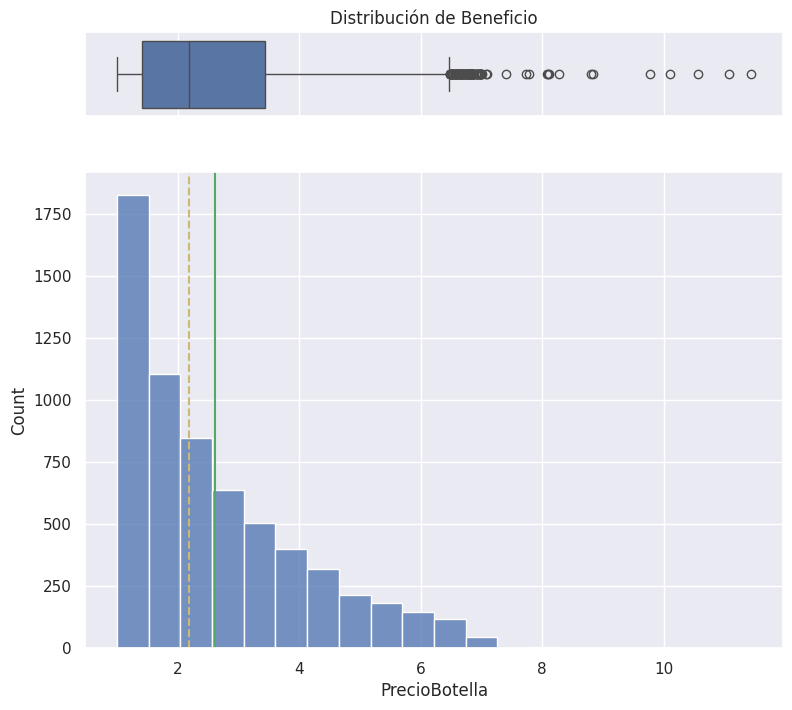

In [32]:
histogram_boxplot(vinos['PrecioBotella'], bins = 20, font_scale=1, title="Distribución de Beneficio")

In [33]:
cat_plot(vinos.Compra)

In [34]:
cat_plot(vinos.Etiqueta)

In the file that I executed early I have some functions to plot depending on the variable being category or continuos.



Cont


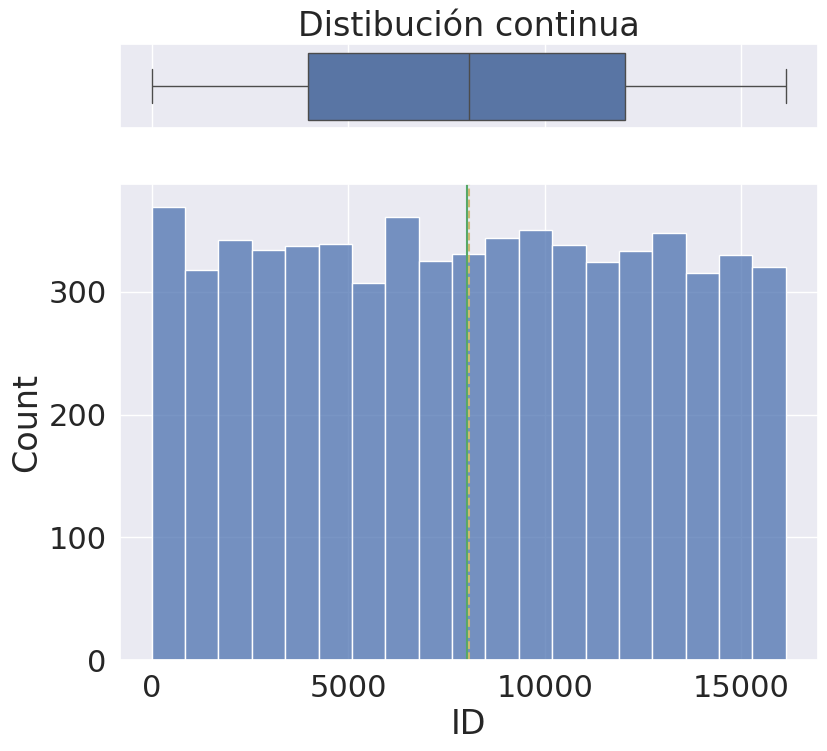

Cont


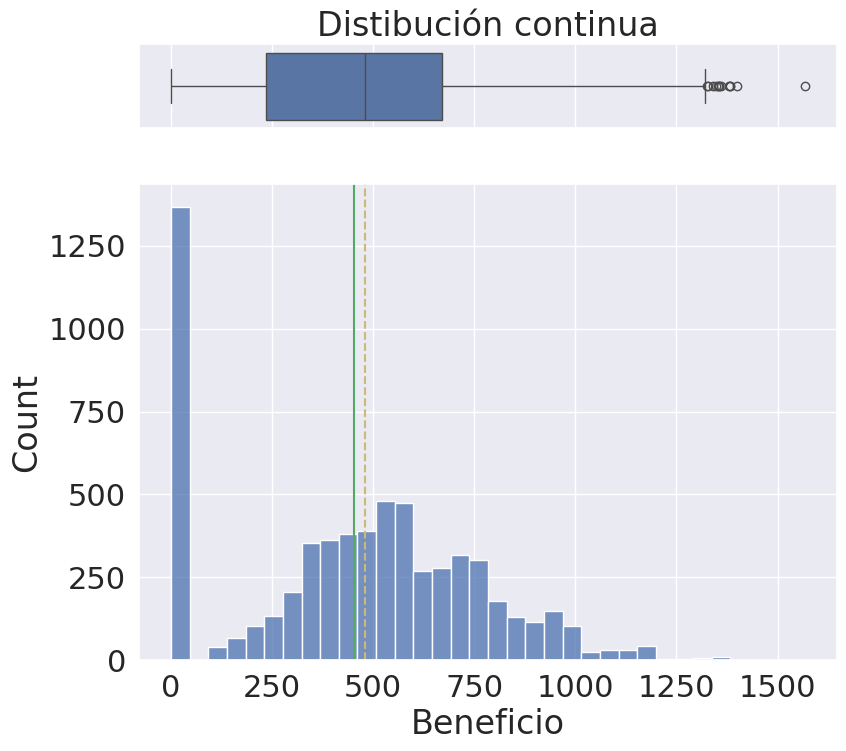

Cat


Cont


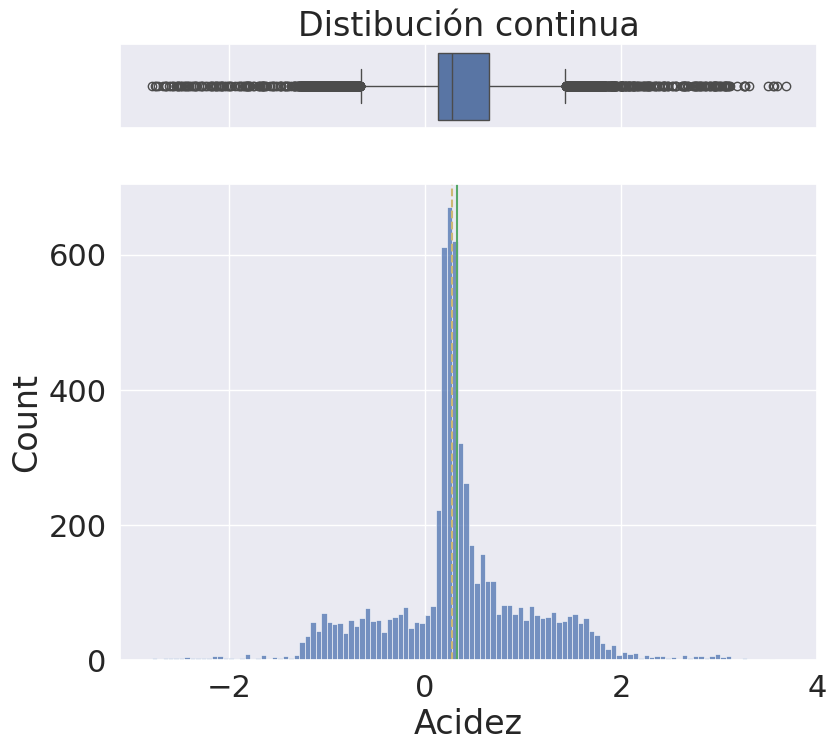

Cont


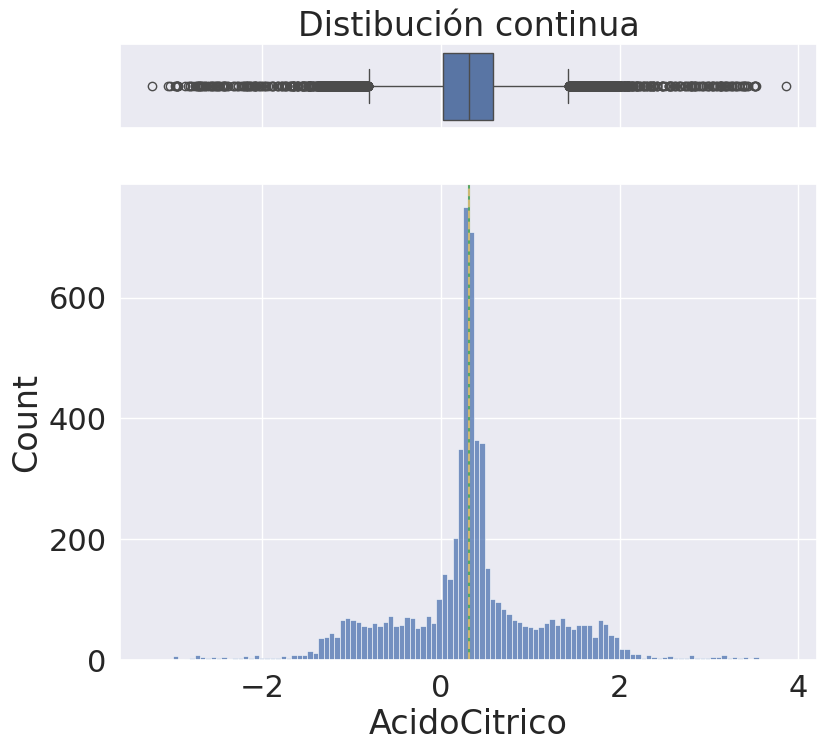

Cont


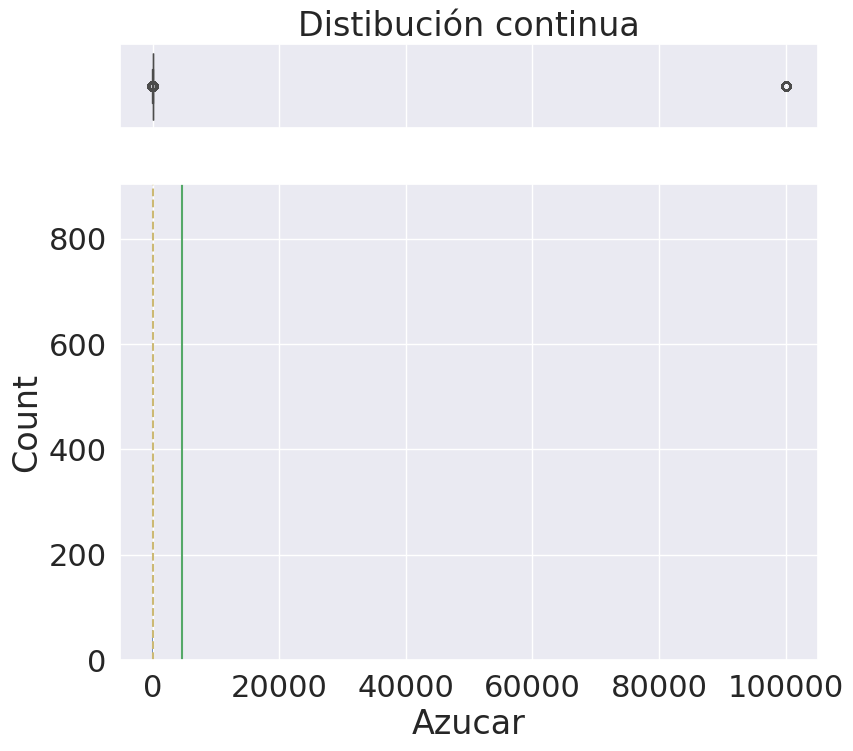

Cont


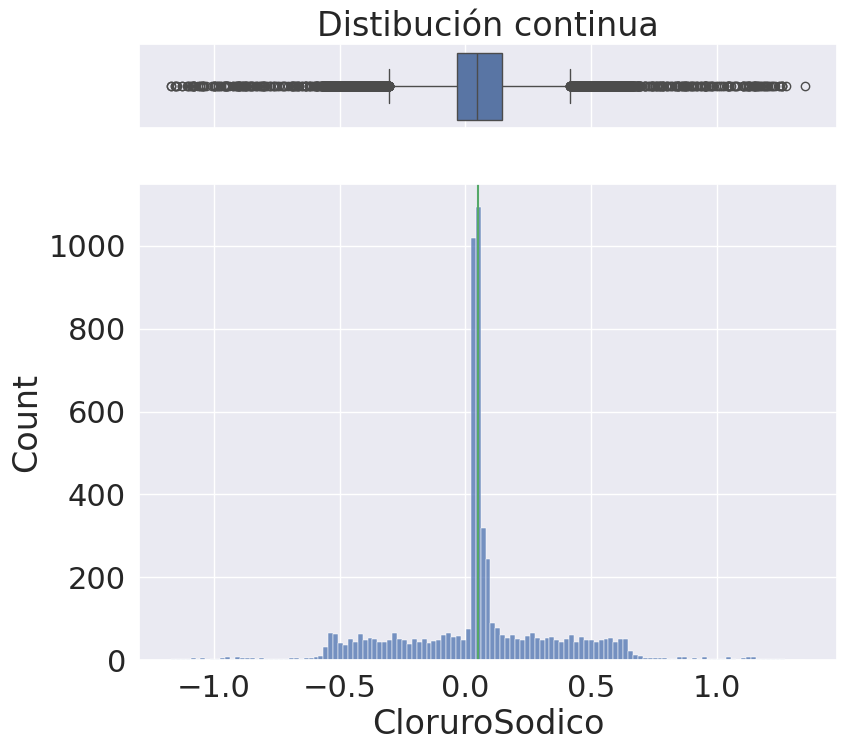

Cont


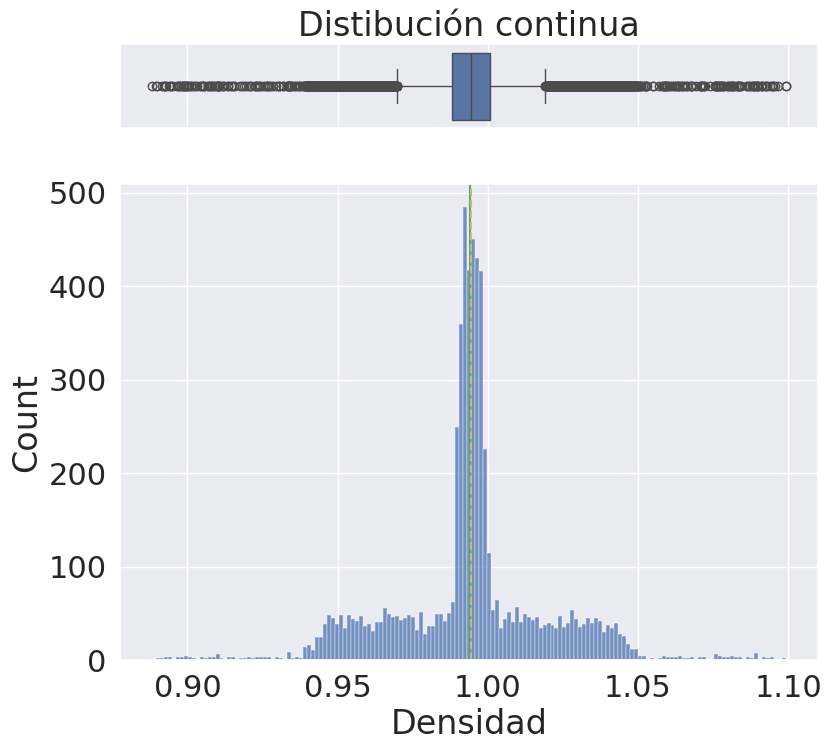

Cont


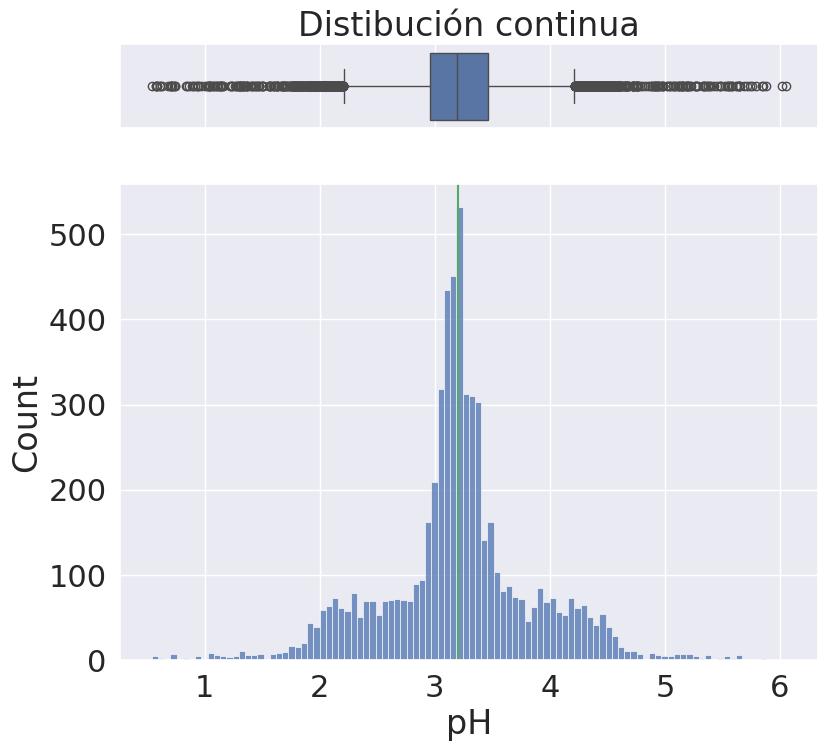

Cont


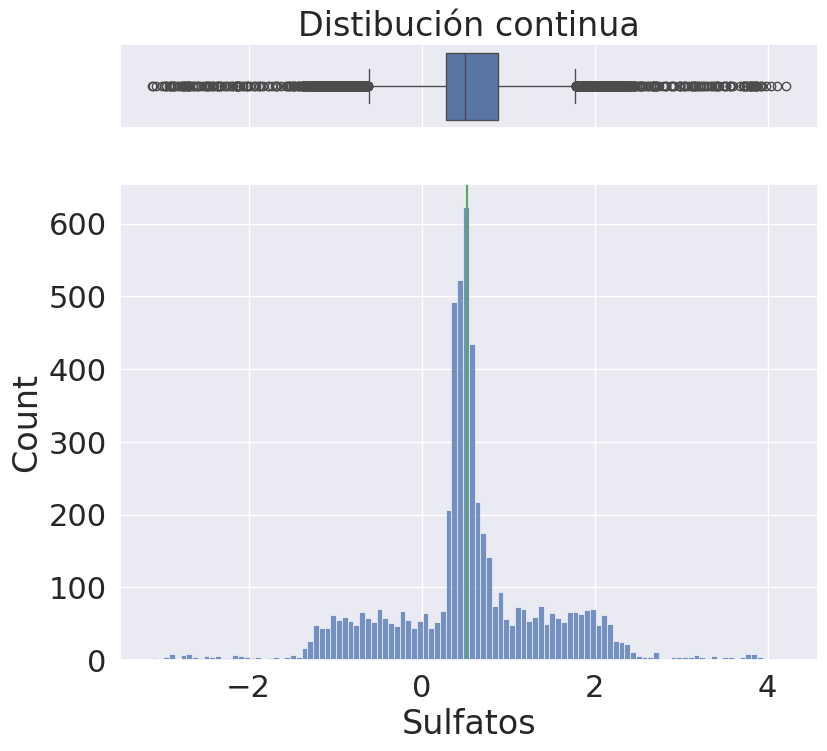

Cont


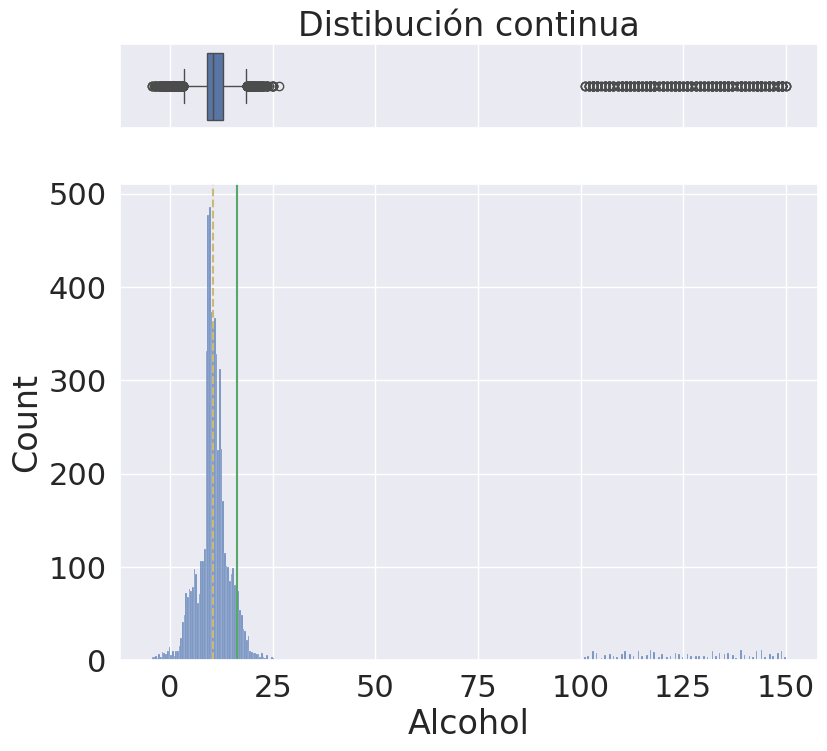

Cat


Cont


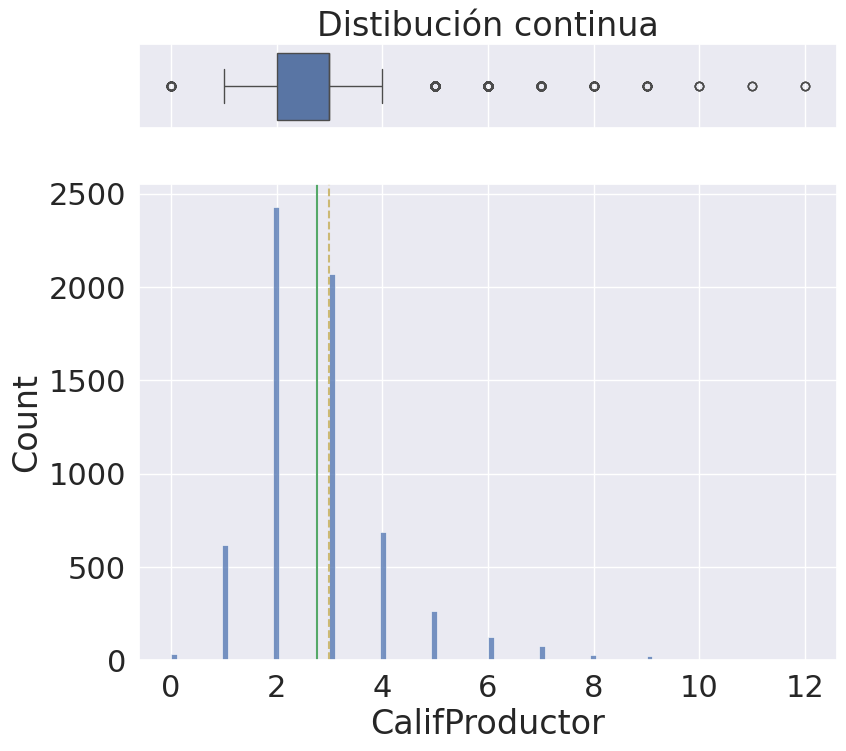

Cat


Cat


Cont


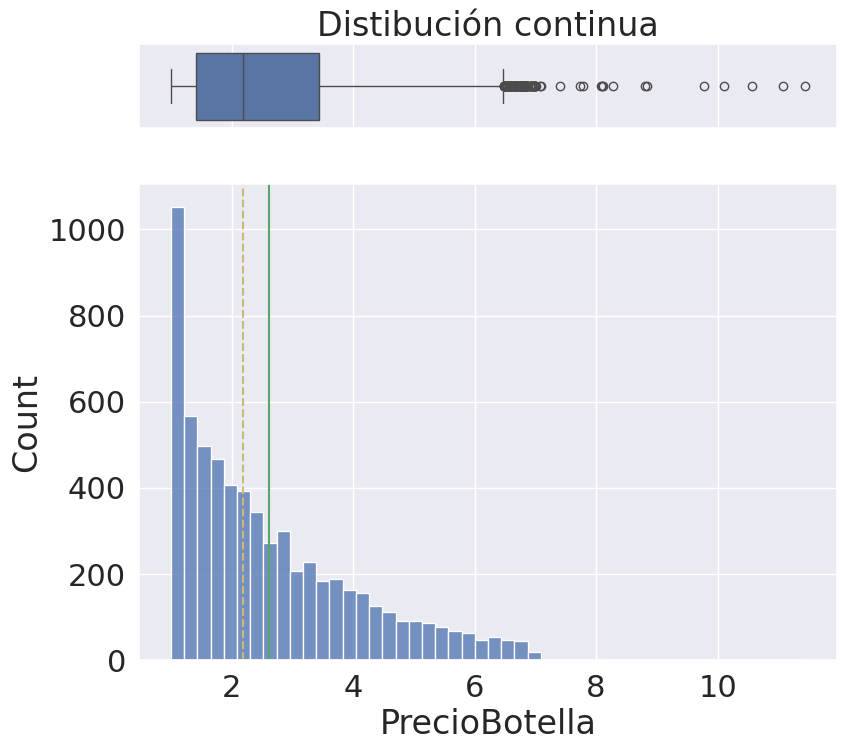

,0
ID,None
Beneficio,None
Compra,None
Acidez,None
AcidoCitrico,None
Azucar,None
CloruroSodico,None
Densidad,None
pH,None
Sulfatos,None


In [35]:
vinos.apply(plot)

# Correction of detected errors
'Etiqueta' has 10 categories and should have 5. We create a frequency table of the categories to investigate further.

---

[ESP] Corrección de errores detectados

1. *Etiqueta* tiene 10 categorías y debería tener 5. Hacemos una tabla de frecuencias de las categorías para indagar.


In [36]:
vinos.Etiqueta.value_counts(sort=False)

,count
Etiqueta,
B,1282
M,1357
MB,191
MM,216
R,2380
b,209
m,230
mb,40
mm,40


In [37]:
# Apply upper function with lambda.
vinos['Etiqueta']=vinos['Etiqueta'].apply(lambda x: x.upper()).astype('category')

vinos['Etiqueta'].value_counts()


,count
Etiqueta,
R,2800
M,1587
B,1491
MM,256
MB,231


Can be also done with str method and then changing again to category type.



In [38]:
# vinos['Etiqueta'] = vinos['Etiqueta'].str.upper().astype('category')


Reorganize the order of the category, this will help further in the modelization, the first category in the order is the reference category for the interpretation.



In [39]:
vinos["Etiqueta"] = vinos["Etiqueta"].cat.reorder_categories(['MM','M','R','B','MB'])

vinos.Etiqueta.value_counts()


,count
Etiqueta,
R,2800
M,1587
B,1491
MM,256
MB,231


In [40]:
# Sort = False to sort the results in the order we arrange the variables
vinos.Etiqueta.value_counts(sort=False)


,count
Etiqueta,
MM,256
M,1587
R,2800
B,1491
MB,231


2. **Sugar.** The plot is completely unreadable... it is clear that there is an undeclared NA with the value 99999. It must be replaced with a true missing value to fix the distribution. It is advisable to use inplace=False when you are not sure, in order to avoid generating errors in the dataset.

---

[ESP] **Azucar**. Tiene un gráfico directamente ilegible...está claro que hay un NA no declarado con valor 99999. Hay que reemplazarlo por un verdadero missing. Es recomendable usar el inplace = False cuando no se está seguro para no generar errores en el dataset.


In [41]:
vinos.Azucar.replace(99999,np.nan,inplace=True)

# Check for the new values
vinos.Azucar.min(),vinos.Azucar.max()


/tmp/ipykernel_14979/3026680135.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





(-127.1, 141.15)

Cont


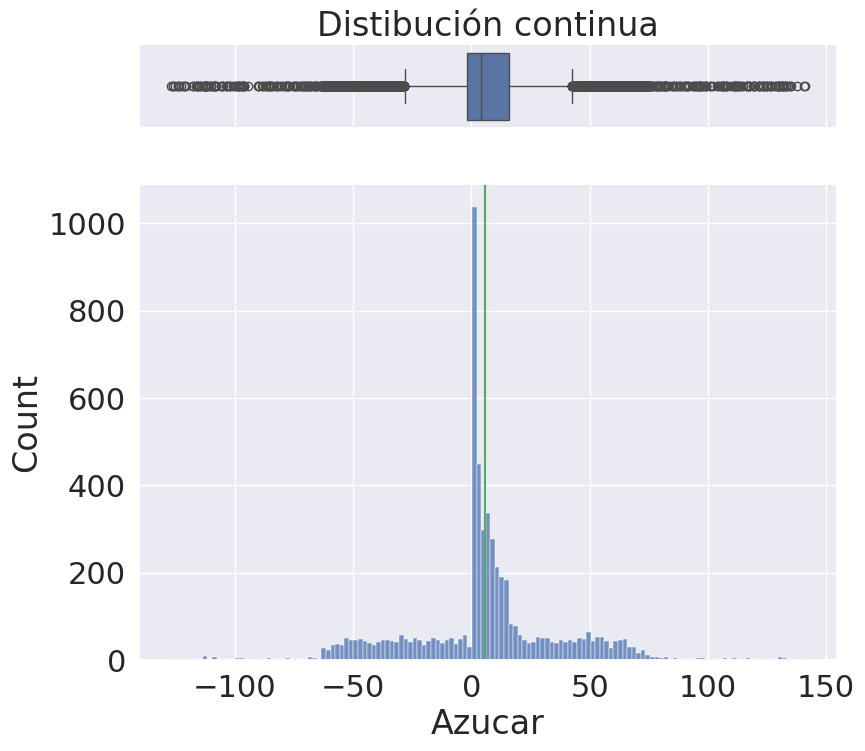

In [42]:
plot(vinos.Azucar)

3. **Alcohol.** The variable information table tells us that it is a percentage and should therefore be restricted to the 0–100 range. Any value outside that range must be treated as a missing value, since we cannot clearly assign it to another value. Here we can use NumPy’s where or pandas’ between.

---
[ESP]
**Alcohol**. La tabla de info de las variables nos dice que es un % y debe estar por tanto restringido al rango 0-100. Todo valor fuera de ese rango habrá que tomarlo como valor perdido pues no podemos asignar claramente a otros valores en principio. Aquí podemos utilizar el *where* de numpy o bien el *between* de pandas.



In [43]:
# Numpy option
#vinos.Alcohol = np.where((vinos['Alcohol'] < 0) | (vinos['Alcohol'] >100), np.nan,vinos.Alcohol)

# Option .loc from pandas
vinos.loc[~vinos.Alcohol.between(0, 100), "Alcohol"] = np.nan

# Check the new values of the variable
vinos.Alcohol.min(),vinos.Alcohol.max()


(0.0, 26.5)

In [44]:
~vinos.Alcohol.between(0, 100)

,Alcohol
0,True
1,False
2,False
3,False
4,False
...,...
6360,False
6361,True
6362,False
6363,False


4. **Clasificación**. We noticed a "?" category, which is unusual. Check whether it is something residual that we can convert to missing and later impute, or whether it is a category with significant volume and a meaningful pattern with respect to the target variable.

---

[ESP] Veíamos esa categoría ? que nos llama la atención. Veamos si se trata de algo residual y podemos pasar a missing para imputar posteriormente o si es una categoría con importancia en volumen y patrón frente al objetivo.



In [45]:
print(vinos.Clasificacion.value_counts())

# Contingency table with the binary target variable 'Compra'
pd.crosstab(index=vinos['Compra'], columns=vinos['Clasificacion'])


Clasificacion
**      1754
?       1680
*       1535
***     1074
****     322
Name: count, dtype: int64


Clasificacion,*,**,***,****,?
Compra,,,,,
0,306,46,0,0,1015
1,1229,1708,1074,322,665


Replace ? with Unknown, since it represents an important category in terms of volume and may show an interesting pattern with respect to the target variable. It can be inferred that wines with unknown classification have a much lower probability of purchase. We use replace for this value replacement task.

---

[ESP] Reemplazar los ? por Desconocido pues representa una categoría importante en volumen y con un posible patrón interesante ante la variable objetivo. Se intuye que los vinos de clasificación desconocida tienen bastante menor probabilidad de compra! utilizamos el *replace* para la tarea de cambio de valores.



In [46]:
vinos.Clasificacion.replace('?','Desconocido',inplace=True)

/tmp/ipykernel_14979/1844499083.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_14979/1844499083.py:1: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.



Once the variables are free of major errors, they are ready for outlier and missing value handling.

We separate the target variables and work on the predictor dataset. It is not common practice to modify the target variables, since they are the supervision variables and are generally assumed to have been correctly recorded.

---

[ESP] Una vez libres de errores graves, las variables están preparadas para la gestión de outliers y missing.

Separamos las variables objetivo y trabajamos en el archivo de predictores. No es habitual tocar las variables objetivo, son las variables de supervisión y se presuponen están bien recogidas.




In [47]:
vinos.Region.info()

<class 'pandas.core.series.Series'>
RangeIndex: 6365 entries, 0 to 6364
Series name: Region
Non-Null Count  Dtype   
--------------  -----   
6258 non-null   category
dtypes: category(1)
memory usage: 6.5 KB


In [48]:
# Rename categories of Region
new_categories = ["Reg %s" % round(g) for g in vinos.Region.cat.categories]
print(new_categories)
vinos.Region = vinos.Region.cat.rename_categories(new_categories)


['Reg 1', 'Reg 2', 'Reg 3']


In [49]:
vinos.Region.value_counts()

,count
Region,
Reg 3,2132
Reg 2,2067
Reg 1,2059


In [50]:
# Separate the target variable
varObjCont = vinos.Beneficio
varObjBin = vinos.Compra
imput = vinos.drop(['Beneficio','Compra'],axis=1)

imput.head()


,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,Etiqueta,CalifProductor,Clasificacion,Region,PrecioBotella
0,2,0.16,-0.81,26.10,-0.425,1.02792,3.38,0.70,NaN,M,2,***,Reg 1,1.00
1,4,2.64,-0.88,14.80,0.037,0.99518,3.12,0.48,22.0,M,3,***,Reg 3,3.38
2,8,0.29,-0.40,21.50,0.060,0.99572,3.49,1.21,10.3,R,3,Desconocido,Reg 1,3.72
3,11,-1.22,0.34,1.40,0.040,1.03236,3.20,NaN,11.6,B,2,***,Reg 2,6.23
4,12,0.27,1.05,11.25,-0.007,0.99620,4.93,0.26,15.0,R,1,Desconocido,Reg 2,2.44


# Outliers

In [51]:
imput.select_dtypes(include=np.number).skew()

,0
ID,0.003339
Acidez,0.029079
AcidoCitrico,-0.024261
Azucar,0.022391
CloruroSodico,0.012041
Densidad,-0.009353
pH,0.003311
Sulfatos,-0.062373
Alcohol,0.267099
CalifProductor,1.663553


Absolute skewness values greater than 1 are a sign of a distribution that is significantly skewed either to the right/positive (+) or to the left/negative (-).

Before handling the values detected as outliers, we assess their incidence in each variable. We evaluate if we have more than 20% of outliers in a variable it may indicate a bimodal distribution, meaning that there are actually two populations within the distribution. If it is a low percentage, we can winsorize without heavily affecting the tails of the distribution or convert them to missing values and then impute the data.

---

[ESP] Asimetrías en valor absoluto mayores a la unidad son signo de distribución significativamente sesgada a la derecha/positiva (+) o izquierda/negativa (-).


Antes de gestionar aquellos valores detectados como outliers, valoramos la incidencia en cada variable,evaluamos si estamos ante un problema grave (tener más de un 20% de valores atípicos en alguna variable es síntoma de distribución bimodal, hay en realidad dos poblaciones jugando en la distribución) o si por el contrario, se trata de un % bajo podemos winsorizar sin cargar mucho las colas o pasar a missing y luego imputar los datos.




In [52]:
## Función manual de winsor con clip+quantile
def winsorize_with_pandas(s, limits):
    """
    s : pd.Series
        Series to winsorize
    limits : tuple of float
        Tuple of the percentages to cut on each side of the array,
        with respect to the number of unmasked data, as floats between 0. and 1
    """
    return s.clip(lower=s.quantile(limits[0], interpolation='lower'),
                  upper=s.quantile(1-limits[1], interpolation='higher'))


In [53]:
## Función para gestionar outliers
def gestiona_outlierss(col,clas = 'check'):

     print(col.name)
     # Check by the skew of the distribution
     if abs(col.skew()) < 1:
        criterio1 = abs((col-col.mean())/col.std())>3
     else:
        criterio1 = abs((col-col.median())/stats.median_abs_deviation(col.dropna()))>6


     q1 = col.quantile(0.25)

     q3 = col.quantile(0.75)

     IQR=q3-q1

     criterio2 = (col<(q1 - 3*IQR))|(col>(q3 + 3*IQR))
     lower = col[criterio1&criterio2&(col<q1)].count()/col.dropna().count()
     upper = col[criterio1&criterio2&(col>q3)].count()/col.dropna().count()

     if clas == 'check':
            lower_p = lower * 100
            upper_p = upper * 100
            total_p = (lower + upper) * 100
            return pd.Series([lower_p, upper_p, total_p], index=["Low", "Up", "Total"])
     elif clas == 'winsor':
            return(winsorize_with_pandas(col,(lower,upper)))
     elif clas == 'miss':
            print('\n MissingAntes: ' + str(col.isna().sum()))
            col.loc[criterio1&criterio2] = np.nan
            print('MissingDespues: ' + str(col.isna().sum()) +'\n')
            return(col)

In [54]:
imput.select_dtypes(include=np.number).apply(lambda x: gestiona_outlierss(x))

ID
Acidez
AcidoCitrico
Azucar
CloruroSodico
Densidad
pH
Sulfatos
Alcohol
CalifProductor
PrecioBotella


,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella
Low,0.0,0.816968,0.848390,0.956307,0.807781,0.942655,0.794165,1.024128,0.000000,0.000000,0.000000
Up,0.0,0.879811,0.785546,0.972795,0.873722,0.942655,0.696921,0.815831,0.317885,0.157109,0.078555
Total,0.0,1.696779,1.633936,1.929101,1.681503,1.885310,1.491086,1.839958,0.317885,0.157109,0.078555


In [55]:
# Create a copy
vinCont = imput.select_dtypes(include=np.number).copy()

# Apply with winsor clas due to the low incidence
vinos_winsor = vinCont.apply(lambda x: gestiona_outliers(x,clas='winsor'))

# vinos_winsor.apply(lambda x: x.isna().sum()/x.count()*100)

ID
Acidez
AcidoCitrico
Azucar
CloruroSodico
Densidad
pH
Sulfatos
Alcohol
CalifProductor
PrecioBotella


Cont


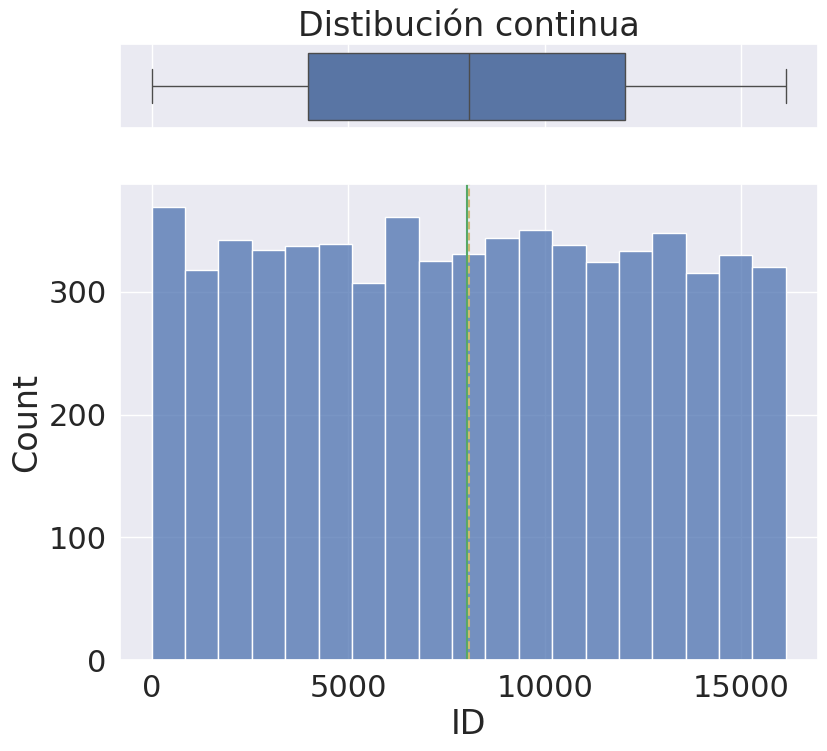

Cont


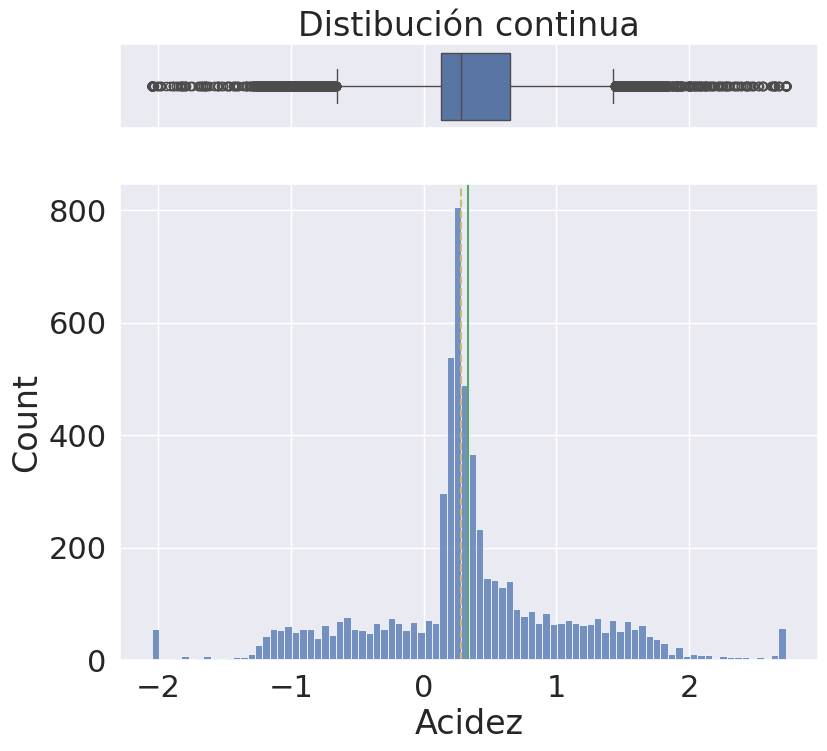

Cont


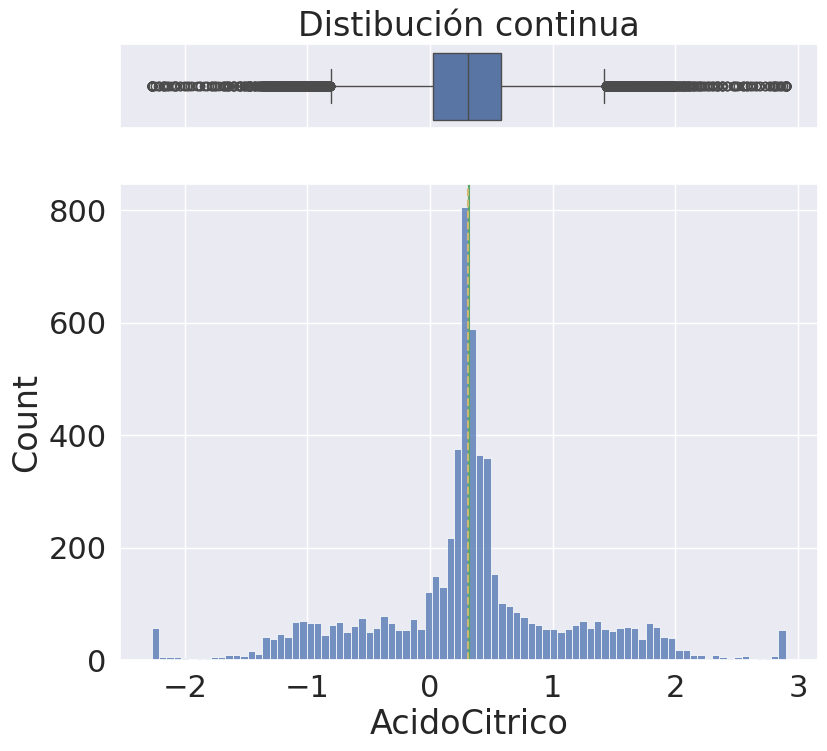

Cont


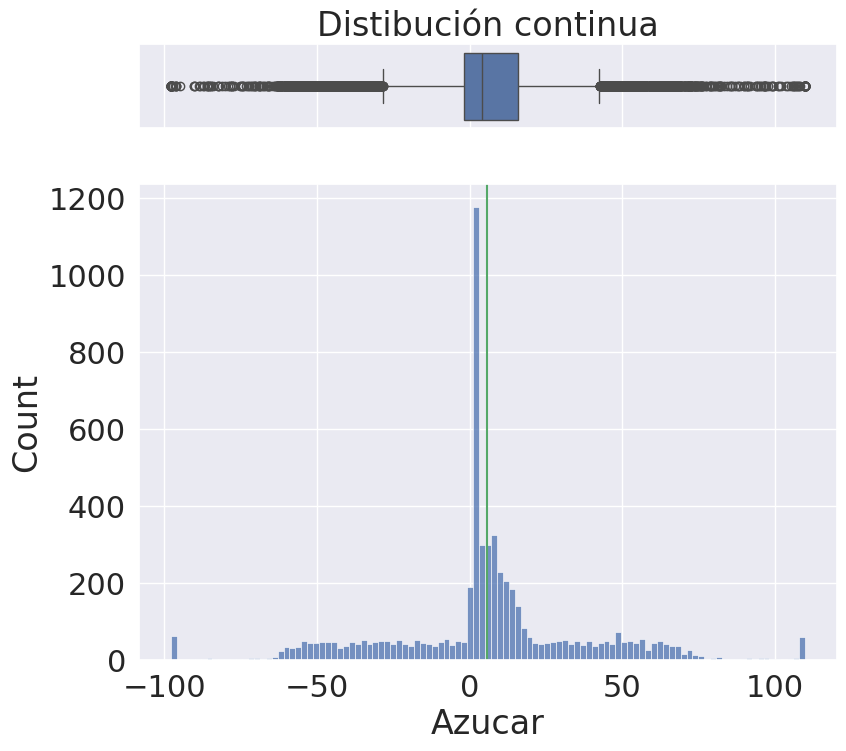

Cont


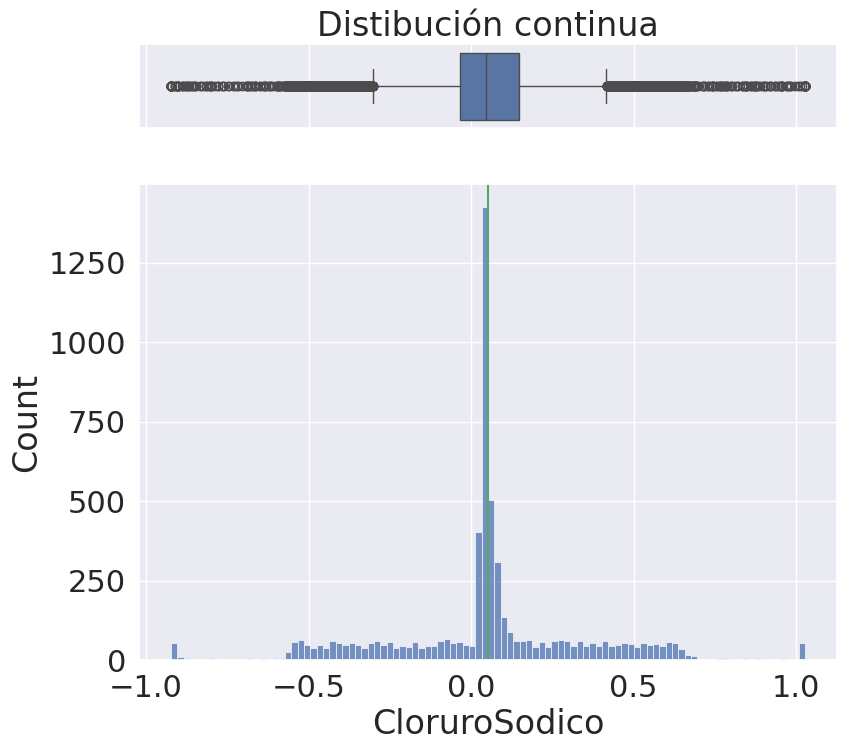

Cont


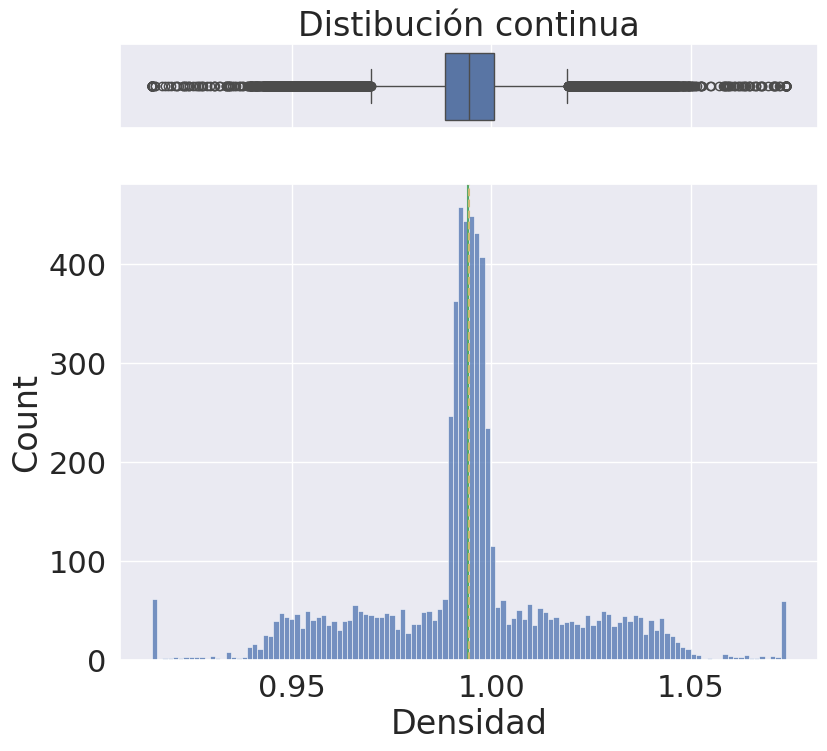

Cont


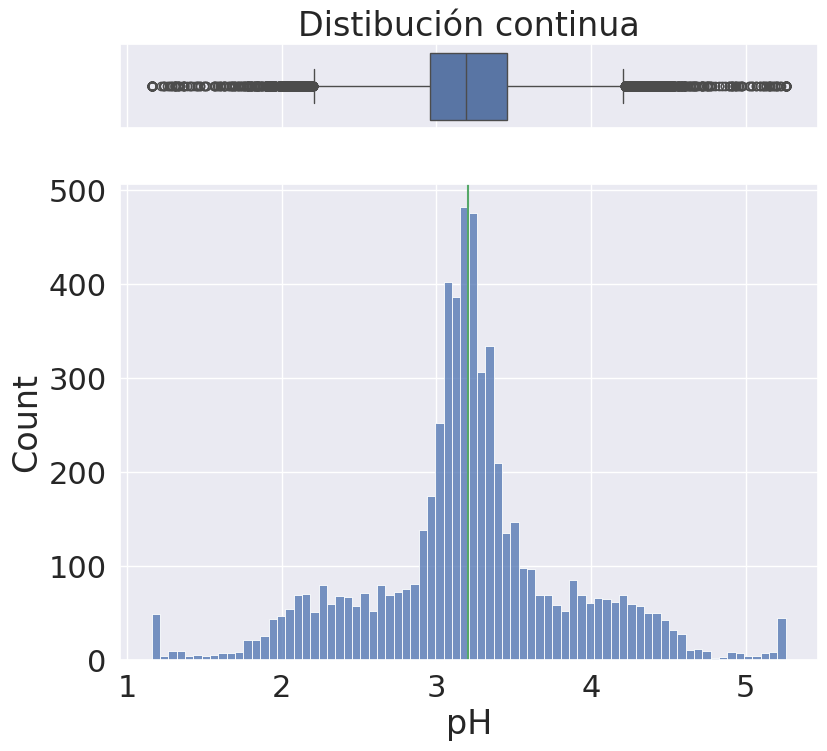

Cont


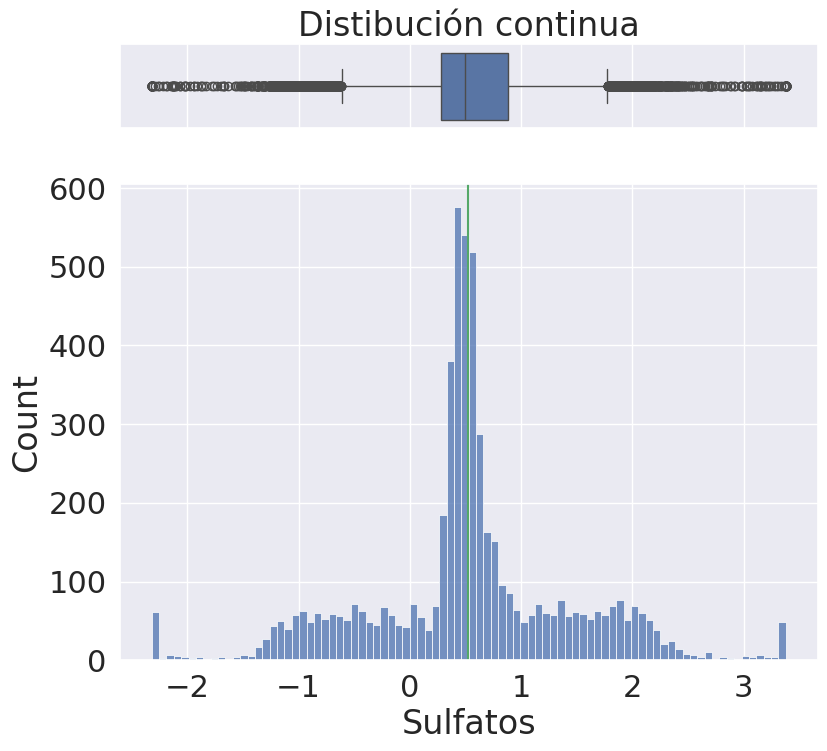

Cont


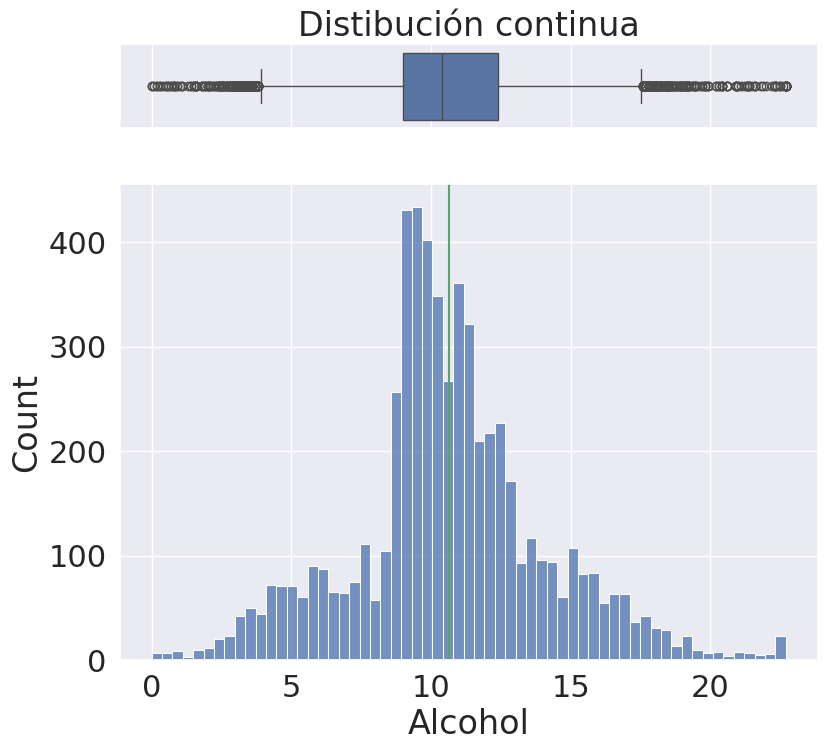

Cont


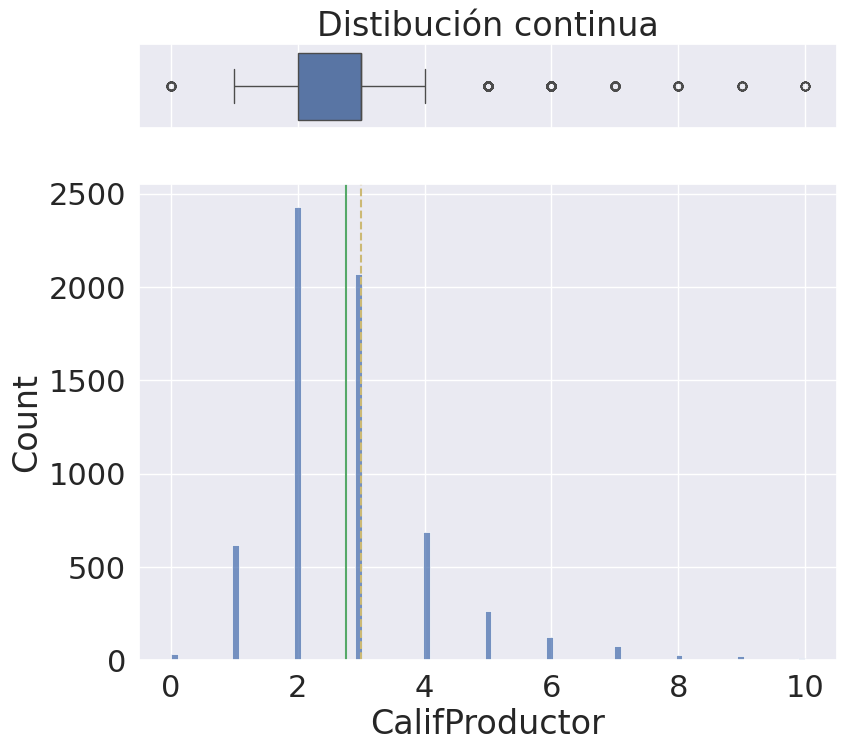

Cont


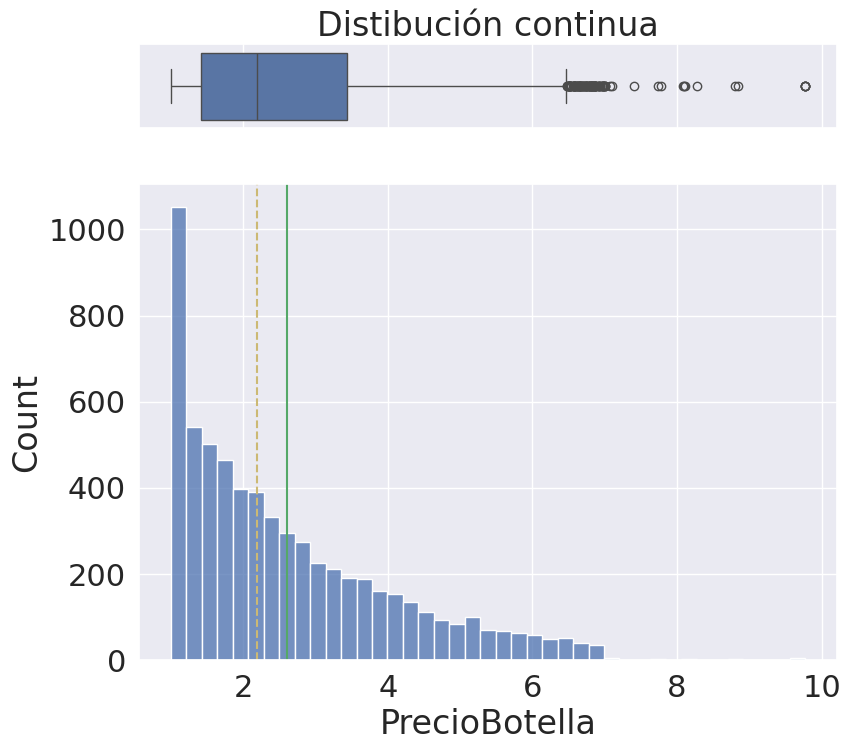

,0
ID,None
Acidez,None
AcidoCitrico,None
Azucar,None
CloruroSodico,None
Densidad,None
pH,None
Sulfatos,None
Alcohol,None
CalifProductor,None


In [56]:
vinos_winsor.apply(plot)

In [57]:
# Join the winsor data with categorical
imput_wins = vinos_winsor.join(imput.select_dtypes(exclude=np.number))
imput_wins

,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,Etiqueta,Clasificacion,Region
0,2,0.16,-0.81,26.10,-0.425,1.02792,3.38,0.70,NaN,2,1.00,M,***,Reg 1
1,4,2.64,-0.88,14.80,0.037,0.99518,3.12,0.48,22.0,3,3.38,M,***,Reg 3
2,8,0.29,-0.40,21.50,0.060,0.99572,3.49,1.21,10.3,3,3.72,R,Desconocido,Reg 1
3,11,-1.22,0.34,1.40,0.040,1.03236,3.20,NaN,11.6,2,6.23,B,***,Reg 2
4,12,0.27,1.05,11.25,-0.007,0.99620,4.93,0.26,15.0,1,2.44,R,Desconocido,Reg 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6360,16111,0.39,0.17,2.30,0.099,1.00223,4.28,0.12,9.8,4,1.28,R,*,Reg 1
6361,16112,0.69,0.09,53.90,0.044,0.99480,3.55,NaN,NaN,2,4.19,MB,***,Reg 3
6362,16113,0.33,-0.94,-42.50,0.036,0.97287,2.99,NaN,14.0,4,1.81,R,**,Reg 1
6363,16127,0.17,-1.10,37.00,0.078,0.99076,3.25,NaN,12.3,1,1.00,R,**,Reg 2


# Missings


In [58]:
#Proportion of missings per variable
imput_wins.apply(lambda x: x.isna().sum()/imput_wins.shape[0]*100)


,0
ID,0.000000
Acidez,0.000000
AcidoCitrico,0.000000
Azucar,4.713276
CloruroSodico,4.697565
Densidad,0.000000
pH,3.063629
Sulfatos,9.489395
Alcohol,6.095837
CalifProductor,0.000000


With this under control, we can see that sulfatos is the most problematic variable, with nearly 10% missing values. Aside from that, the missing-value levels are relatively low.

**Missing values per observation.**
This will later help us during the modeling stage to determine whether there is any pattern among records with multiple missing values.

---

[ESP] Vemos que sulfatos es la variable más peligrosa con casi un 10% de perdidos..Digamos que es la variable en la que mayores dudas tenemos respecto a la conservación de su distribución tras la imputación. Por lo demás, valores relativamente bajos.


- **Missings por observación**.

Esto nos sirve luego en nuestra etapa de modelado para ver si hay algún patron con los registros con múltiples missings.


In [59]:
#Proportion of missings for each variable
imput_wins['n_missings'] = imput_wins.apply(lambda x: x.isna().sum(),axis=1)

imput_wins.n_missings.describe()


,n_missings
count,6365.000000
mean,0.297408
std,0.531238
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,3.000000


In [60]:
imput_wins.sort_values(by='n_missings', ascending=False).head()



,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,Etiqueta,Clasificacion,Region,n_missings
1344,3341,0.26,0.27,18.2,0.048,1.04227,NaN,NaN,3.8,1,2.62,B,**,NaN,3
4385,11020,0.27,-0.01,NaN,0.295,0.99566,NaN,-0.46,NaN,3,2.35,R,**,Reg 2,3
2781,6990,1.40,0.30,NaN,NaN,1.04263,4.0,NaN,15.1,3,1.30,R,**,Reg 2,3
3341,8429,-0.65,1.00,-8.2,0.310,0.94903,NaN,NaN,12.5,4,1.01,R,**,NaN,3
728,1813,0.81,-0.19,8.4,0.051,0.99756,NaN,NaN,14.8,3,3.13,R,***,NaN,3


It can be observed that the incidence per record has a maximum of 3 missing variables per observation, which is manageable.

**Coexistence and patterns of missing values**

We can examine the correlation in the presence of missing values to assess whether there is any pattern in how they occur. If we observe such patterns, we can decide on the most appropriate imputation method.

---

[ESP] Se puede observar que la incidencia por registro tiene un máximo de 3 variables perdidas por registro, asequible.


Podemos echar un vistazo a la correlación en la existencia de missings para valorar si existe algún patrón de aparición de los mismos. En caso de que observemos patrones de aparición, podemos decidir el método más adecuado para imputar.




<Axes: >

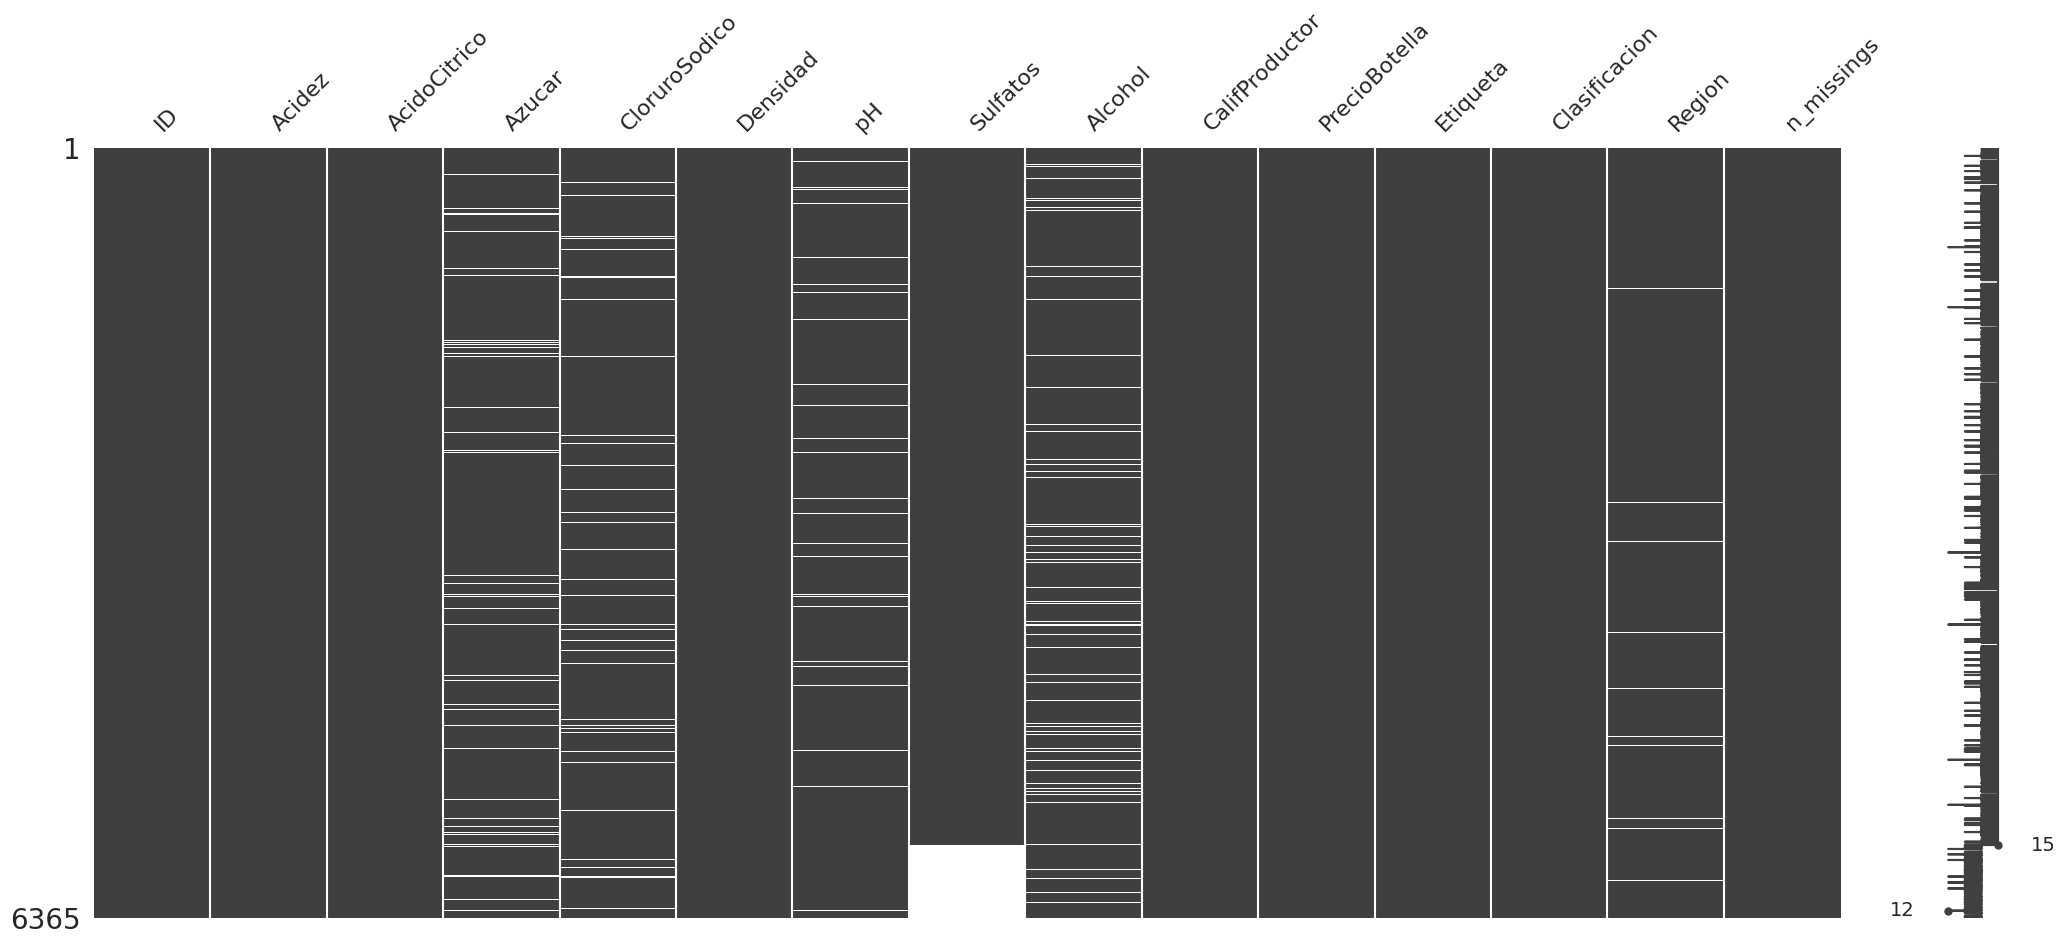

In [61]:
!pip install missingno
import missingno as msno

# Plot correlation heatmap of missingness
msno.matrix(imput_wins.sort_values(by='Sulfatos'))


No patterns of missing value occurrence are easily discernible.

Let's look at this in the heat map that represents the correlation value in the 0-1 matrix indicating the presence or absence of missing values in each record-variable combination. If the correlation is high, it means that missing values are likely to be found in the same records for those two variables, which would indicate a co-occurrence pattern, and the risk of biases due to missing values would be greater.

---

[ESP] No se intuyen patrones de aparición de missings con facilidad.  

Veamos esto en el mapa de calor que representa el valor de correlación en la matriz 0-1 de aparación o no de perdidos en cada registro-variable. Si la correlación es alta, significa que es probable encontrar perdidos en los mismos registros para esas dos variables, con lo cual habría un patrón de coexistencia y el peligro de sesgos debidos a los valores perdidos sería mayor.


<Axes: >

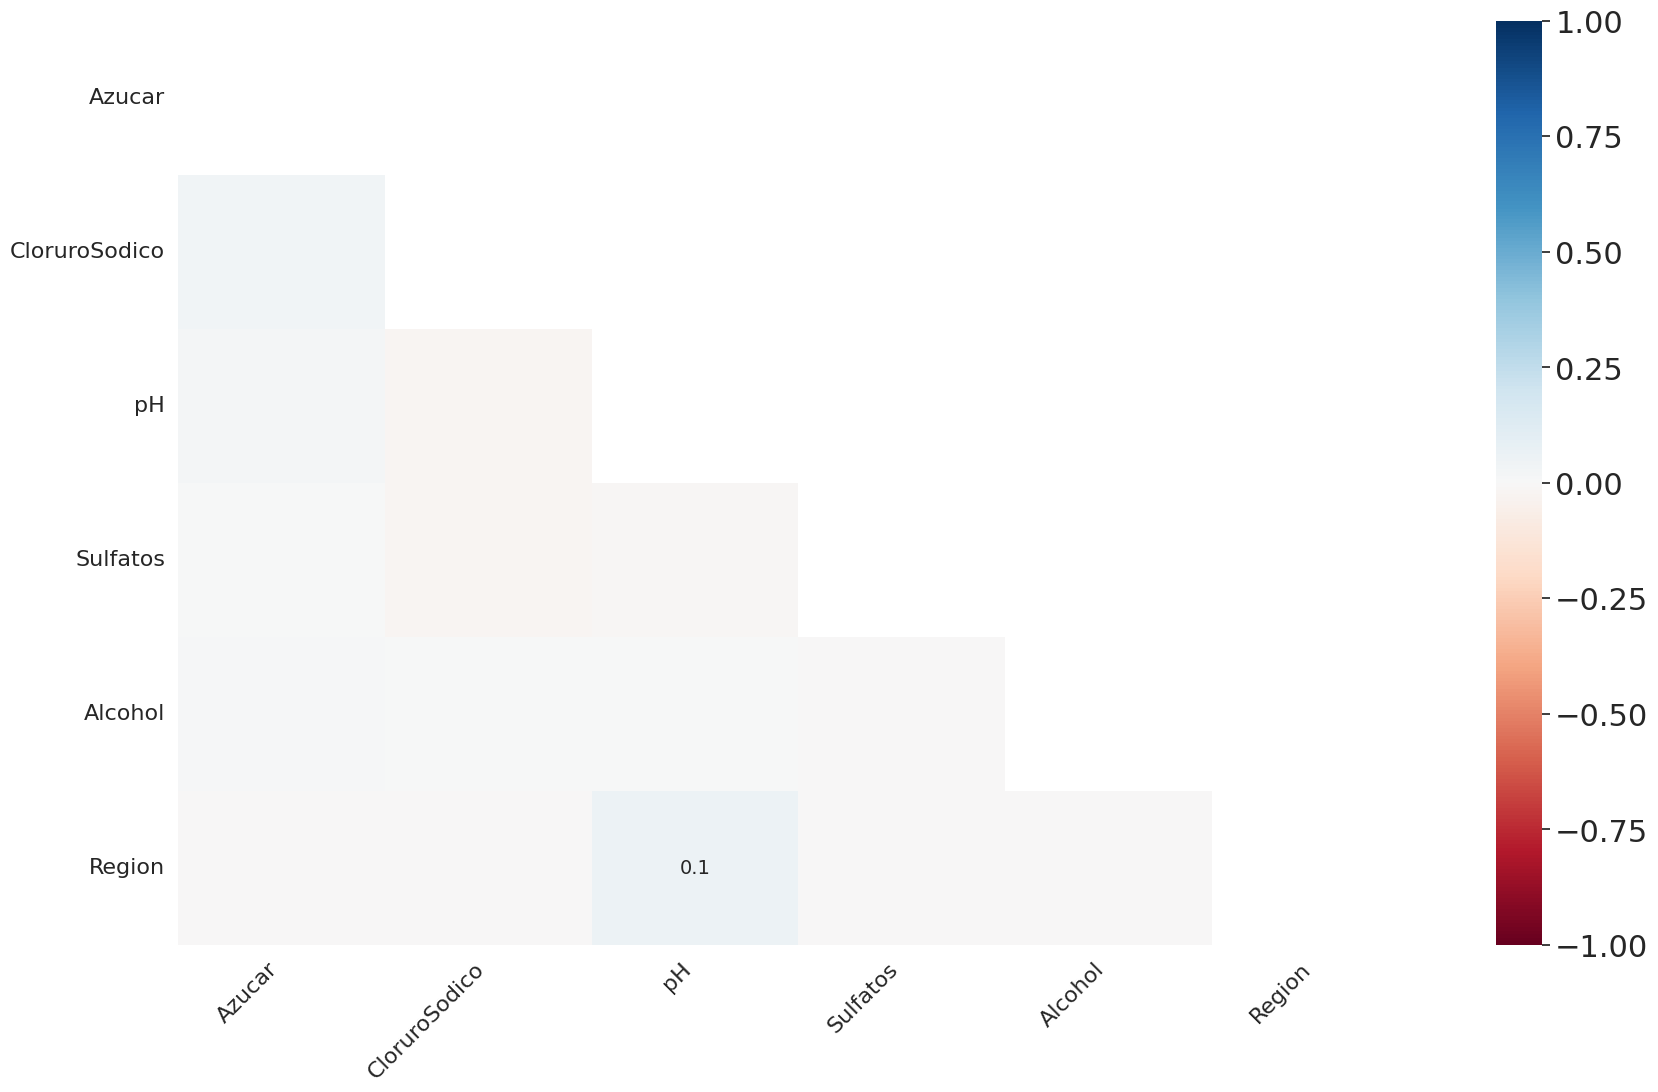

In [62]:
msno.heatmap(imput_wins)

Very weak relationships, with that maximum of 0.1 for pH with Region. Nothing noteworthy.

##Imputations

At this point, we have confirmed that the incidence of missing values is not concerning in general (with sulfatos having that 10% keep an eye), so we are going to opt for data imputation in order to maintain the largest possible sample base for fitting future models to the data.

We could wonder what would happen if we removed NAs by listwise deletion from the dataset. How many observations would we lose? Are the variables with the highest load of missing values really relevant for a potential model?

---

[ESP] Relaciones muy débiles con ese máximo de 0.1 para pH con Región. Nada destacable.


Llegados a este punto, hemos comprobado que la incidencia de valores perdidos no es preocupante en general (con sulfatos con ese 10% que nos invita a estar atentos) por lo que vamos a decidirnos por la imputación de los datos de cara a mantener la mayor base muestral posible para el ajuste de los futuros modelos a los datos.

Nos puede la curiosidad y nos planteamos que pasaría si elimináramos los NAs por lista del dataset. Cuantas observaciones perderíamos? Las variables que mayor carga de perdidos presentan, son realmente relevantes para un posible modelo?


In [63]:
imput_wins.dropna().info()

<class 'pandas.core.frame.DataFrame'>
Index: 4692 entries, 1 to 6360
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              4692 non-null   int64   
 1   Acidez          4692 non-null   float64 
 2   AcidoCitrico    4692 non-null   float64 
 3   Azucar          4692 non-null   float64 
 4   CloruroSodico   4692 non-null   float64 
 5   Densidad        4692 non-null   float64 
 6   pH              4692 non-null   float64 
 7   Sulfatos        4692 non-null   float64 
 8   Alcohol         4692 non-null   float64 
 9   CalifProductor  4692 non-null   int64   
 10  PrecioBotella   4692 non-null   float64 
 11  Etiqueta        4692 non-null   category
 12  Clasificacion   4692 non-null   category
 13  Region          4692 non-null   category
 14  n_missings      4692 non-null   int64   
dtypes: category(3), float64(9), int64(3)
memory usage: 490.8 KB


We are left with 4,692 records in total for all variables, which represents 73% of the information in the file. Eliminating 27% of records...

Conclusion: let's impute!

Some options from the sklearn and feature_engine packages for simple and multivariate imputations of various types are useful for this.

We will define the available imputers and then apply them to the data.

---

[ESP] Nos quedamos con 4692 registros en total para todas las variables, lo que supone un 73% de la información del archivo. Eliminando el 27% de registros..

Conclusión, imputemos!

Algunas posibilidades de los paquetes *sklearn* y *feature_engine* para imputaciones simples y multivariantes de varios tipos sirven para esto.

Definiremos los imputadores disponibles y posteriormente los aplicaremos a los datos.


In [64]:
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer
#!pip install feature-engine

# Moda: Solo nominales
imputer_moda = skl_imp.SimpleImputer(strategy='most_frequent', missing_values=np.nan)

# knn: Solo numéricas
imputer_knn = skl_imp.KNNImputer(n_neighbors=3)

# Chain equations: solo numéricas
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

#conda install feature_engine
import feature_engine.imputation as fe_imp

# Aleatoria: numéricas y nominales
imputer_rand = fe_imp.RandomSampleImputer()

# Mediana: solo numéricas
imputer_median = fe_imp.MeanMedianImputer(imputation_method='median')

# Media: solo numericas
imputer_mean = fe_imp.MeanMedianImputer(imputation_method='mean')

!python -V

Python 3.12.13


We will divide again the dataset to apply the imputations for continuos and categorical variables, then join again.



In [65]:
imput_wins_cont = imput_wins.select_dtypes(include=np.number)
imput_wins_cat = imput_wins.select_dtypes(exclude=np.number)
imput_wins_cont.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              6365 non-null   int64  
 1   Acidez          6365 non-null   float64
 2   AcidoCitrico    6365 non-null   float64
 3   Azucar          6065 non-null   float64
 4   CloruroSodico   6066 non-null   float64
 5   Densidad        6365 non-null   float64
 6   pH              6170 non-null   float64
 7   Sulfatos        5761 non-null   float64
 8   Alcohol         5977 non-null   float64
 9   CalifProductor  6365 non-null   int64  
 10  PrecioBotella   6365 non-null   float64
 11  n_missings      6365 non-null   int64  
dtypes: float64(9), int64(3)
memory usage: 596.8 KB


### Options for numerical variables:

1- **Univariate level**

Mean, median, or random.


In [66]:
# Mean
vinos_winsor_mean_imputed = imputer_mean.fit_transform(imput_wins_cont)#.transform(imput_wins_cont)
vinos_winsor_mean_imputed.describe().round(1)

,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,n_missings
count,6365.0,6365.0,6365.0,6365.0,6365.0,6365.0,6365.0,6365.0,6365.0,6365.0,6365.0,6365.0
mean,8010.7,0.3,0.3,5.7,0.1,1.0,3.2,0.5,10.6,2.8,2.6,0.3
std,4654.9,0.8,0.8,32.8,0.3,0.0,0.7,0.9,3.4,1.3,1.5,0.5
min,2.0,-2.0,-2.3,-97.8,-0.9,0.9,1.2,-2.3,0.0,0.0,1.0,0.0
25%,3980.0,0.1,0.0,0.9,-0.0,1.0,3.0,0.3,9.1,2.0,1.4,0.0
50%,8065.0,0.3,0.3,5.0,0.0,1.0,3.2,0.5,10.6,3.0,2.2,0.0
75%,12027.0,0.6,0.6,15.0,0.1,1.0,3.4,0.8,12.2,3.0,3.4,1.0
max,16128.0,2.7,2.9,109.9,1.0,1.1,5.3,3.4,22.7,10.0,9.8,3.0


In [67]:
# Median
vinos_winsor_median_imputed = imputer_median.fit(imput_wins_cont).transform(imput_wins_cont)
vinos_winsor_median_imputed.describe()


,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,n_missings
count,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000
mean,8010.702278,0.331342,0.315038,5.629018,0.050955,0.994214,3.201887,0.524987,10.612553,2.760094,2.610008,0.297408
std,4654.939139,0.769865,0.842346,32.811900,0.308634,0.025679,0.654404,0.881329,3.401447,1.310444,1.476877,0.531238
min,2.000000,-2.050000,-2.270000,-97.800000,-0.923000,0.914730,1.160000,-2.320000,0.000000,0.000000,1.000000,0.000000
25%,3980.000000,0.130000,0.020000,0.900000,-0.004000,0.988245,2.980000,0.330000,9.100000,2.000000,1.420000,0.000000
50%,8065.000000,0.280000,0.310000,4.100000,0.046000,0.994400,3.190000,0.500000,10.400000,3.000000,2.190000,0.000000
75%,12027.000000,0.650000,0.580000,15.000000,0.124000,1.000600,3.450000,0.770000,12.200000,3.000000,3.440000,1.000000
max,16128.000000,2.730000,2.900000,109.900000,1.027000,1.073900,5.260000,3.380000,22.700000,10.000000,9.770000,3.000000


In [68]:
vinos_winsor_mean_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              6365 non-null   int64  
 1   Acidez          6365 non-null   float64
 2   AcidoCitrico    6365 non-null   float64
 3   Azucar          6365 non-null   float64
 4   CloruroSodico   6365 non-null   float64
 5   Densidad        6365 non-null   float64
 6   pH              6365 non-null   float64
 7   Sulfatos        6365 non-null   float64
 8   Alcohol         6365 non-null   float64
 9   CalifProductor  6365 non-null   int64  
 10  PrecioBotella   6365 non-null   float64
 11  n_missings      6365 non-null   int64  
dtypes: float64(9), int64(3)
memory usage: 596.8 KB


2. Nivel **multivariante**

KNN nearest neighbors, takes the values of similar records;

or Iterative chain equations. There are more ways to do it...


In [69]:
imputer_knn.fit_transform(imput_wins_cont)

array([[ 2.0000e+00,  1.6000e-01, -8.1000e-01, ...,  2.0000e+00,
         1.0000e+00,  1.0000e+00],
       [ 4.0000e+00,  2.6400e+00, -8.8000e-01, ...,  3.0000e+00,
         3.3800e+00,  0.0000e+00],
       [ 8.0000e+00,  2.9000e-01, -4.0000e-01, ...,  3.0000e+00,
         3.7200e+00,  0.0000e+00],
       ...,
       [ 1.6113e+04,  3.3000e-01, -9.4000e-01, ...,  4.0000e+00,
         1.8100e+00,  1.0000e+00],
       [ 1.6127e+04,  1.7000e-01, -1.1000e+00, ...,  1.0000e+00,
         1.0000e+00,  1.0000e+00],
       [ 1.6128e+04,  3.2000e-01,  1.2000e-01, ...,  1.0000e+00,
         2.7900e+00,  1.0000e+00]])

In [70]:
# Fit/transform
imput_wins_knn_imputed = pd.DataFrame(imputer_knn.fit_transform(imput_wins_cont),columns=imput_wins_cont.columns)
imput_wins_itImp_imputed = pd.DataFrame(imputer_itImp.fit_transform(imput_wins_cont),columns=imput_wins_cont.columns)


In [71]:
imput_wins_itImp_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              6365 non-null   float64
 1   Acidez          6365 non-null   float64
 2   AcidoCitrico    6365 non-null   float64
 3   Azucar          6365 non-null   float64
 4   CloruroSodico   6365 non-null   float64
 5   Densidad        6365 non-null   float64
 6   pH              6365 non-null   float64
 7   Sulfatos        6365 non-null   float64
 8   Alcohol         6365 non-null   float64
 9   CalifProductor  6365 non-null   float64
 10  PrecioBotella   6365 non-null   float64
 11  n_missings      6365 non-null   float64
dtypes: float64(12)
memory usage: 596.8 KB


### Options for nominal variables:
For categorical variables, we can use mode (the most represented category) or random.




In [72]:
imput_wins_moda_imputed = pd.DataFrame(imputer_moda.fit_transform(imput_wins_cat),columns=imput_wins_cat.columns)

imput_wins_moda_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Etiqueta       6365 non-null   object
 1   Clasificacion  6365 non-null   object
 2   Region         6365 non-null   object
dtypes: object(3)
memory usage: 149.3+ KB


At this point, we could generate the dataset with a custom imputation configuration by combining the imputed numerical columns with the imputed categorical columns. For this case I´m going to use knn and most common.

---

[ESP] En este punto podríamos generar el dataset de configuración personalizada de imputaciones juntando las columnas numéricas imputadas con las categóricas imputadas.



In [73]:
vinos_wins_knn_moda = pd.concat([imput_wins_knn_imputed,imput_wins_moda_imputed.astype('category'),varObjCont,varObjBin], axis=1)
vinos_wins_knn_moda.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              6365 non-null   float64 
 1   Acidez          6365 non-null   float64 
 2   AcidoCitrico    6365 non-null   float64 
 3   Azucar          6365 non-null   float64 
 4   CloruroSodico   6365 non-null   float64 
 5   Densidad        6365 non-null   float64 
 6   pH              6365 non-null   float64 
 7   Sulfatos        6365 non-null   float64 
 8   Alcohol         6365 non-null   float64 
 9   CalifProductor  6365 non-null   float64 
 10  PrecioBotella   6365 non-null   float64 
 11  n_missings      6365 non-null   float64 
 12  Etiqueta        6365 non-null   category
 13  Clasificacion   6365 non-null   category
 14  Region          6365 non-null   category
 15  Beneficio       6365 non-null   int64   
 16  Compra          6365 non-null   category
dtypes: category(4)

In [74]:
print(vinos.describe())
vinos_wins_knn_moda.describe()


                 ID    Beneficio       Acidez  AcidoCitrico       Azucar  \
count   6365.000000  6365.000000  6365.000000   6365.000000  6065.000000   
mean    8010.702278   452.380204     0.331214      0.314350     5.710330   
std     4654.939139   308.380542     0.787534      0.861428    34.497308   
min        2.000000     0.000000    -2.790000     -3.240000  -127.100000   
25%     3980.000000   236.000000     0.130000      0.020000    -1.700000   
50%     8065.000000   480.000000     0.280000      0.310000     4.100000   
75%    12027.000000   671.000000     0.650000      0.580000    16.000000   
max    16128.000000  1568.000000     3.680000      3.860000   141.150000   

       CloruroSodico     Densidad           pH     Sulfatos      Alcohol  \
count    6066.000000  6365.000000  6170.000000  5761.000000  5977.000000   
mean        0.051348     0.994204     3.202207     0.526659    10.630534   
std         0.322715     0.026417     0.678330     0.948039     3.525277   
min        

,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,n_missings,Beneficio
count,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000,6365.000000
mean,8010.702278,0.331342,0.315038,5.655858,0.051653,0.994214,3.201969,0.530570,10.637581,2.760094,2.610008,0.297408,452.380204
std,4654.939139,0.769865,0.842346,33.102045,0.311317,0.025679,0.657888,0.895724,3.437872,1.310444,1.476877,0.531238,308.380542
min,2.000000,-2.050000,-2.270000,-97.800000,-0.923000,0.914730,1.160000,-2.320000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,3980.000000,0.130000,0.020000,-3.000000,-0.036667,0.988245,2.960000,0.276667,9.000000,2.000000,1.420000,0.000000,236.000000
50%,8065.000000,0.280000,0.310000,4.100000,0.046000,0.994400,3.190000,0.500000,10.400000,3.000000,2.190000,0.000000,480.000000
75%,12027.000000,0.650000,0.580000,16.100000,0.150000,1.000600,3.460000,0.880000,12.400000,3.000000,3.440000,1.000000,671.000000
max,16128.000000,2.730000,2.900000,109.900000,1.027000,1.073900,5.260000,3.380000,22.700000,10.000000,9.770000,3.000000,1568.000000


Select an option an save the file.


In [75]:
vinos_wins_knn_moda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              6365 non-null   float64 
 1   Acidez          6365 non-null   float64 
 2   AcidoCitrico    6365 non-null   float64 
 3   Azucar          6365 non-null   float64 
 4   CloruroSodico   6365 non-null   float64 
 5   Densidad        6365 non-null   float64 
 6   pH              6365 non-null   float64 
 7   Sulfatos        6365 non-null   float64 
 8   Alcohol         6365 non-null   float64 
 9   CalifProductor  6365 non-null   float64 
 10  PrecioBotella   6365 non-null   float64 
 11  n_missings      6365 non-null   float64 
 12  Etiqueta        6365 non-null   category
 13  Clasificacion   6365 non-null   category
 14  Region          6365 non-null   category
 15  Beneficio       6365 non-null   int64   
 16  Compra          6365 non-null   category
dtypes: category(4)

### We could also use a random imputer for all variables but it is not the best because it is random :)


In [76]:
imput_wins_rand_imputed = imputer_rand.fit_transform(imput_wins)
imput_wins_rand_imputed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6365 entries, 0 to 6364
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              6365 non-null   int64   
 1   Acidez          6365 non-null   float64 
 2   AcidoCitrico    6365 non-null   float64 
 3   Azucar          6365 non-null   float64 
 4   CloruroSodico   6365 non-null   float64 
 5   Densidad        6365 non-null   float64 
 6   pH              6365 non-null   float64 
 7   Sulfatos        6365 non-null   float64 
 8   Alcohol         6365 non-null   float64 
 9   CalifProductor  6365 non-null   int64   
 10  PrecioBotella   6365 non-null   float64 
 11  Etiqueta        6365 non-null   category
 12  Clasificacion   6365 non-null   category
 13  Region          6365 non-null   category
 14  n_missings      6365 non-null   int64   
dtypes: category(3), float64(9), int64(3)
memory usage: 616.0 KB


# Decision making and saving the depurated file for modelization



In [79]:
# Save in hdfs, it keeps the Dtypes of variables
vinos_wins_knn_moda.to_hdf('/content/drive/MyDrive/Data_Projects/DatosVinoDep_winKnnModa.h5',key='df',format='table')

# Check
vn=pd.read_hdf('/content/drive/MyDrive/Data_Projects/DatosVinoDep_winKnnModa.h5','df')
vn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6365 entries, 0 to 6364
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              6365 non-null   float64 
 1   Acidez          6365 non-null   float64 
 2   AcidoCitrico    6365 non-null   float64 
 3   Azucar          6365 non-null   float64 
 4   CloruroSodico   6365 non-null   float64 
 5   Densidad        6365 non-null   float64 
 6   pH              6365 non-null   float64 
 7   Sulfatos        6365 non-null   float64 
 8   Alcohol         6365 non-null   float64 
 9   CalifProductor  6365 non-null   float64 
 10  PrecioBotella   6365 non-null   float64 
 11  n_missings      6365 non-null   float64 
 12  Etiqueta        6365 non-null   category
 13  Clasificacion   6365 non-null   category
 14  Region          6365 non-null   category
 15  Beneficio       6365 non-null   int64   
 16  Compra          6365 non-null   category
dtypes: category(4), flo